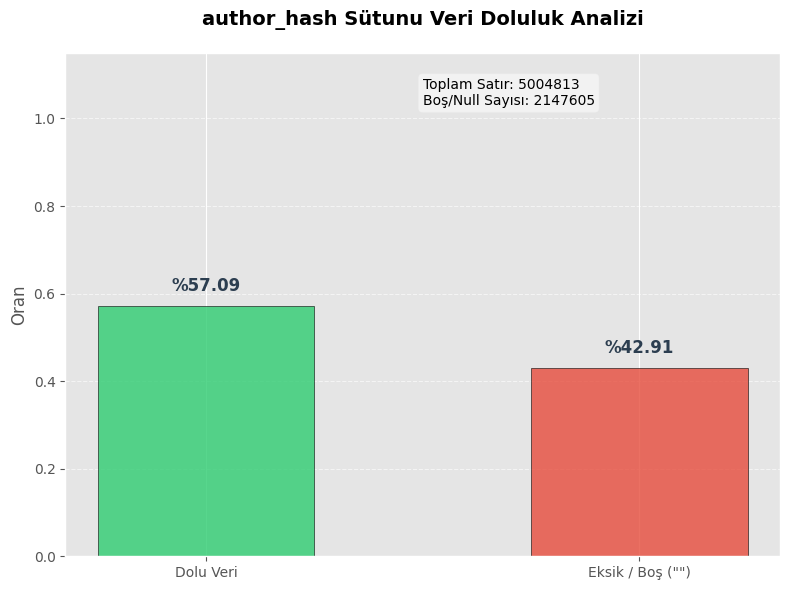

--- DETAYLI ANALİZ ---
Toplam Satır Sayısı: 5004813
Eksik (Null veya ""): 2147605
Eksiklik Oranı: %42.91


In [1]:
import polars as pl
import matplotlib.pyplot as plt

# =============================================================
# 1) VERİ HAZIRLIĞI VE HESAPLAMA
# =============================================================
df = pl.read_parquet("datathonFINAL.parquet")
total = df.height

# "Boş" tanımını hem Null hem de "" (boş metin) olacak şekilde güncelliyoruz
# Polars'ın en hızlı yöntemiyle her iki durumu topluyoruz
stats = df.select([
    ((pl.col("author_hash").is_null()) | (pl.col("author_hash") == "")).sum().alias("empty_total")
])

empty_count = stats["empty_total"][0]
empty_ratio = empty_count / total
filled_ratio = 1 - empty_ratio

# =============================================================
# 2) GÖRSELLEŞTİRME GÜÇLENDİRİLDİ
# =============================================================

# Modern stil ve Türkçe font ayarı
plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

labels = ["Dolu Veri", "Eksik / Boş (\"\")"]
values = [filled_ratio, empty_ratio]
colors = ['#2ecc71', '#e74c3c'] # Canlı Yeşil ve Uyarı Kırmızısı

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=colors, edgecolor='black', alpha=0.8, width=0.5)

# Bar üzerindeki yüzdelik etiketleri (Kalın ve belirgin)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'%{height*100:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 8),  # Yazıyı 8 birim yukarı taşı
                textcoords="offset points",
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='#2c3e50')

# Grafik Başlık ve Eksen Düzenlemeleri
plt.title("author_hash Sütunu Veri Doluluk Analizi", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Oran", fontsize=12)
plt.ylim(0, 1.15) # Üstten pay bırak (etiketler sığsın diye)

# Arka plan ızgara çizgileri
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Grafik üzerine küçük bir özet kutusu ekleme
info_text = f"Toplam Satır: {total}\nBoş/Null Sayısı: {empty_count}"
plt.text(0.5, 0.95, info_text, transform=ax.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

# Konsol çıktıları
print(f"--- DETAYLI ANALİZ ---")
print(f"Toplam Satır Sayısı: {total}")
print(f"Eksik (Null veya \"\"): {empty_count}")
print(f"Eksiklik Oranı: %{empty_ratio*100:.2f}")

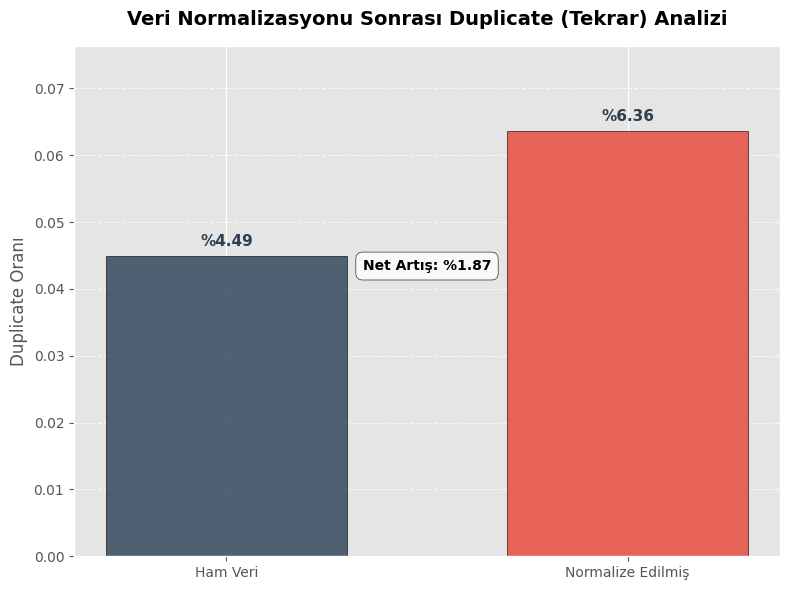

--- ANALİZ SONUÇLARI ---
Ham duplicate oranı: %4.49
Normalize sonrası:   %6.36
Artış miktarı:       %1.87


In [2]:
import polars as pl
import matplotlib.pyplot as plt

# =============================================================
# 1) VERİ İŞLEME (MANTIK DEĞİŞMEDİ)
# =============================================================
df = pl.read_parquet("datathonFINAL.parquet")

raw_total = df.height
raw_unique = df.select(pl.col("original_text").n_unique()).item()
raw_duplicate_ratio = 1 - (raw_unique / raw_total)

df_norm = df.with_columns(
    pl.col("original_text")
    .str.to_lowercase()
    .str.replace_all(r"https?://\S+|www\.\S+", "")
    .str.replace_all(r"@[\w_]+", "")
    .str.replace_all(r"#", "")
    .str.replace_all(r"[^\w\s]", "")
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
    .alias("normalized_text")
)

norm_total = df_norm.height
norm_unique = df_norm.select(pl.col("normalized_text").n_unique()).item()
norm_duplicate_ratio = 1 - (norm_unique / norm_total)
increase = norm_duplicate_ratio - raw_duplicate_ratio

# =============================================================
# 2) GÖRSELLEŞTİRME GÜÇLENDİRİLDİ
# =============================================================

# Stil ve yazı tipi ayarları
plt.style.use('ggplot') # Daha modern bir görünüm
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

labels = ["Ham Veri", "Normalize Edilmiş"]
values = [raw_duplicate_ratio, norm_duplicate_ratio]
colors = ['#34495e', '#e74c3c'] # Koyu gri-mavi ve dikkat çekici bir kırmızı

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=colors, edgecolor='black', alpha=0.85, width=0.6)

# Değer etiketlerini barın üzerine yazdırma (Yüzdelik formatta)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'%{height*100:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 birim yukarı kaydır
                textcoords="offset points",
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#2c3e50')

# Grafik başlık ve etiketlerini düzenleme
plt.title("Veri Normalizasyonu Sonrası Duplicate (Tekrar) Analizi", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Duplicate Oranı", fontsize=12)
plt.ylim(0, max(values) * 1.2) # Yazıların sığması için üstten pay bırak

# Artış oranını grafiğe şık bir kutu içinde ekleme
plt.text(0.5, (raw_duplicate_ratio + norm_duplicate_ratio) / 2.5, 
         f"Net Artış: %{increase * 100:.2f}", 
         ha="center", va="center", fontsize=10, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='black', alpha=0.8))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Konsol çıktılarını da düzenli verelim
print(f"--- ANALİZ SONUÇLARI ---")
print(f"Ham duplicate oranı: %{raw_duplicate_ratio*100:.2f}")
print(f"Normalize sonrası:   %{norm_duplicate_ratio*100:.2f}")
print(f"Artış miktarı:       %{increase * 100:.2f}")

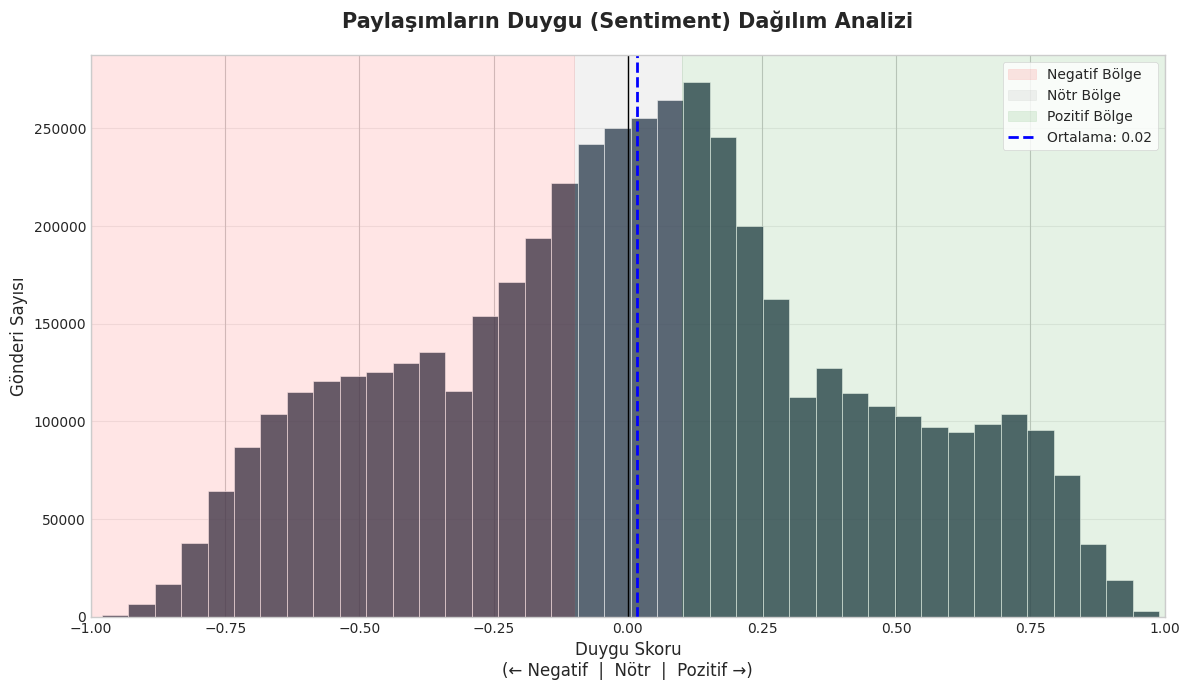

--- DUYGU ANALİZİ ÖZETİ ---
Ortalama Skor: 0.0178
Pozitif Oranı: %41.35
Negatif Oranı: %37.49


In [3]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# 1. Veri Yükleme
df = pl.read_parquet("datathonFINAL.parquet")

# Duygu verisini alıp boş değerleri temizliyoruz
sentiment_data = df.select(pl.col("sentiment")).to_pandas()["sentiment"].dropna()

# 2. Görselleştirme Ayarları
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Temiz bir görünüm
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Histogram Çizimi
# bins=40 genellikle duygu dağılımı için daha dengeli bir görünüm sunar
n, bins, patches = plt.hist(sentiment_data, bins=40, color='#2c3e50', edgecolor='white', alpha=0.8)

# 3. Anlamlandırma: Renkli Bölgeler (Negatif, Nötr, Pozitif)
# Arka planı duygu bölgelerine göre boyuyoruz
plt.axvspan(-1, -0.1, color='red', alpha=0.1, label='Negatif Bölge')
plt.axvspan(-0.1, 0.1, color='gray', alpha=0.1, label='Nötr Bölge')
plt.axvspan(0.1, 1, color='green', alpha=0.1, label='Pozitif Bölge')

# 4. İstatistiksel Göstergeler
mean_val = sentiment_data.mean()
plt.axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Ortalama: {mean_val:.2f}')
plt.axvline(0, color='black', linewidth=1) # Tam merkez çizgisi

# 5. Başlık ve Etiketlerin Türkçeleştirilmesi
plt.title("Paylaşımların Duygu (Sentiment) Dağılım Analizi", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Duygu Skoru\n(← Negatif  |  Nötr  |  Pozitif →)", fontsize=12)
plt.ylabel("Gönderi Sayısı", fontsize=12)

# Eksen sınırlarını netleştirme
plt.xlim(-1, 1)

# Bilgi kutusunu (Legend) yerleştirme
plt.legend(loc='upper right', frameon=True, facecolor='white')

# Izgara ve düzen
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Konsol Özeti
print(f"--- DUYGU ANALİZİ ÖZETİ ---")
print(f"Ortalama Skor: {mean_val:.4f}")
print(f"Pozitif Oranı: %{(sentiment_data > 0.1).mean()*100:.2f}")
print(f"Negatif Oranı: %{(sentiment_data < -0.1).mean()*100:.2f}")

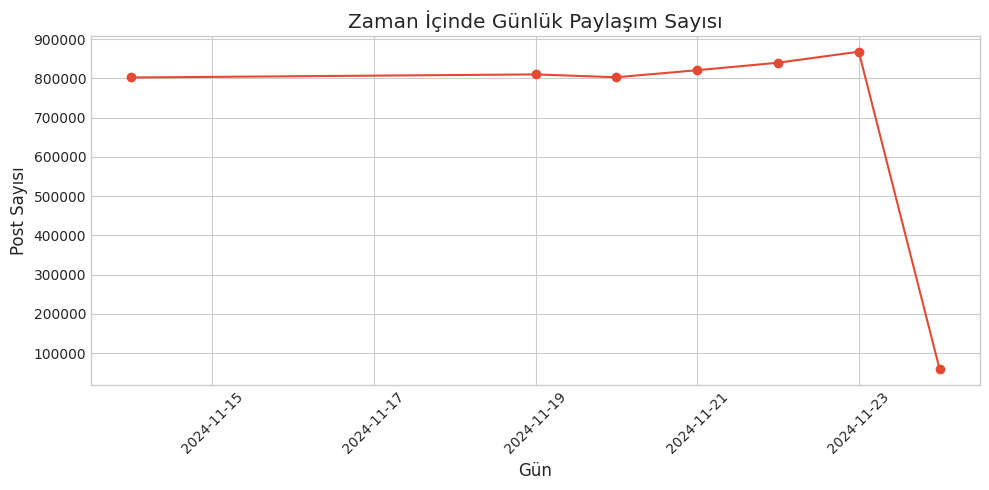

In [4]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet("datathonFINAL.parquet")

df_time = (
    df.with_columns(
        pl.col("date")
        .str.to_datetime("%Y-%m-%dT%H:%M:%S%.fZ")
        .alias("dt")
    )
)

daily_counts = (
    df_time
    .with_columns(pl.col("dt").dt.date().alias("day"))
    .group_by("day")
    .agg(pl.len().alias("count"))
    .sort("day")
)

pdf = daily_counts.to_pandas()

plt.figure(figsize=(10,5))
plt.plot(pdf["day"], pdf["count"], marker="o")

plt.title("Zaman İçinde Günlük Paylaşım Sayısı")
plt.xlabel("Gün")
plt.ylabel("Post Sayısı")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

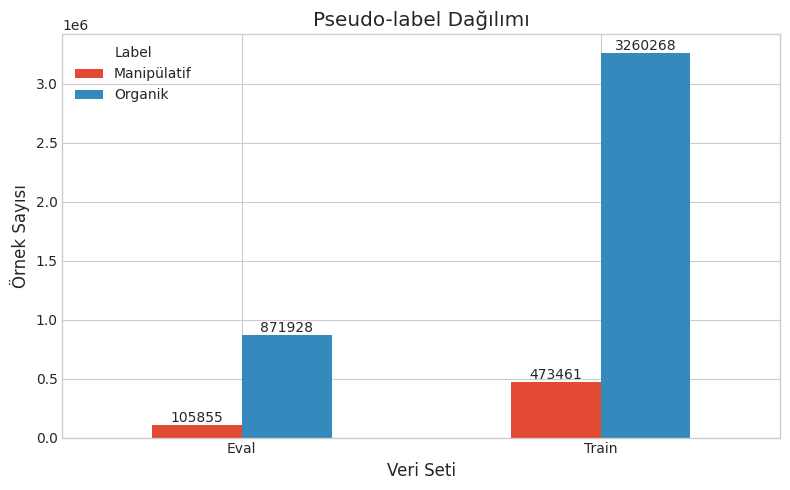

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

label_df = pd.DataFrame({
    "Set": ["Train", "Train", "Eval", "Eval"],
    "Label": ["Organik", "Manipülatif", "Organik", "Manipülatif"],
    "Count": [3260268, 473461, 871928, 105855]
})

pivot = label_df.pivot(index="Set", columns="Label", values="Count")

ax = pivot.plot(kind="bar", figsize=(8,5))

plt.title("Pseudo-label Dağılımı")
plt.xlabel("Veri Seti")
plt.ylabel("Örnek Sayısı")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

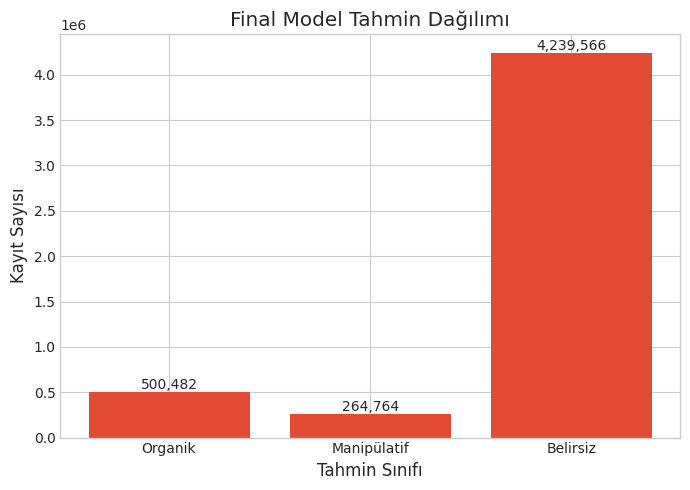

In [6]:
import matplotlib.pyplot as plt

labels = ["Organik", "Manipülatif", "Belirsiz"]
values = [500482, 264764, 4239566]

plt.figure(figsize=(7,5))
plt.bar(labels, values)

plt.title("Final Model Tahmin Dağılımı")
plt.xlabel("Tahmin Sınıfı")
plt.ylabel("Kayıt Sayısı")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

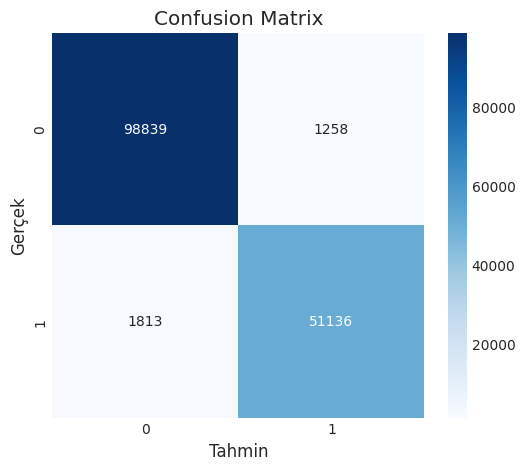

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[98839, 1258],
               [1813, 51136]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")

plt.show()

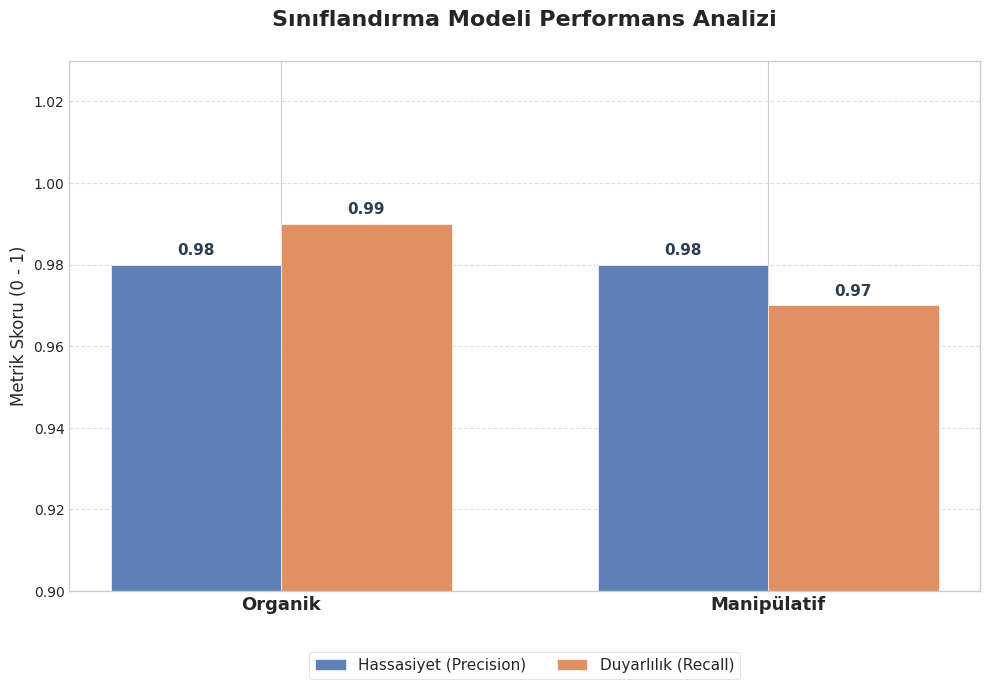

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Veri Hazırlığı
labels = ["Organik", "Manipülatif"]
precision = [0.98, 0.98]
recall = [0.99, 0.97]

x = np.arange(len(labels))  # Etiketlerin konumu
width = 0.35                # Bar genişliği

# 2. Grafik Tasarımı ve Stil Ayarları
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, ax = plt.subplots(figsize=(10, 7))

# Barların oluşturulması
# Renk seçimi: Profesyonel mavi ve turuncu tonları
rects1 = ax.bar(x - width/2, precision, width, label='Hassasiyet (Precision)', 
                color='#4c72b0', edgecolor='white', alpha=0.9)
rects2 = ax.bar(x + width/2, recall, width, label='Duyarlılık (Recall)', 
                color='#dd8452', edgecolor='white', alpha=0.9)

# 3. Değer Etiketlerini Ekleme Fonksiyonu
def autolabel(rects):
    """Her barın üzerine yüksekliğini (değerini) metin olarak ekler."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 birim dikey kaydırma
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='#2c3e50')

autolabel(rects1)
autolabel(rects2)

# 4. Detaylandırma ve Türkçeleştirme
ax.set_title('Sınıflandırma Modeli Performans Analizi', fontsize=16, fontweight='bold', pad=25)
ax.set_ylabel('Metrik Skoru (0 - 1)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13, fontweight='bold')

# Y ekseni sınırlarını performansa göre optimize etme
ax.set_ylim(0.90, 1.03) 

# Lejantı (Bilgi kutusu) alta, daha şık bir şekilde yerleştirme
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=True, fontsize=11)

# Arka plan yardımcı çizgileri
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Grafiği düzenle ve göster
plt.tight_layout()
plt.show()